# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, detect anomalies, identify relationships between features, and generate insights before preprocessing and model building.

The objective is not only to visualize the data but also to answer meaningful questions that will guide feature engineering and model selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
train_df = pd.read_csv("../data/raw/train.csv")

# 1. Target Variable Analysis

### Question

Is the trip duration normally distributed?

Understanding the distribution of the target variable helps determine whether transformations such as logarithmic scaling are required before model training.

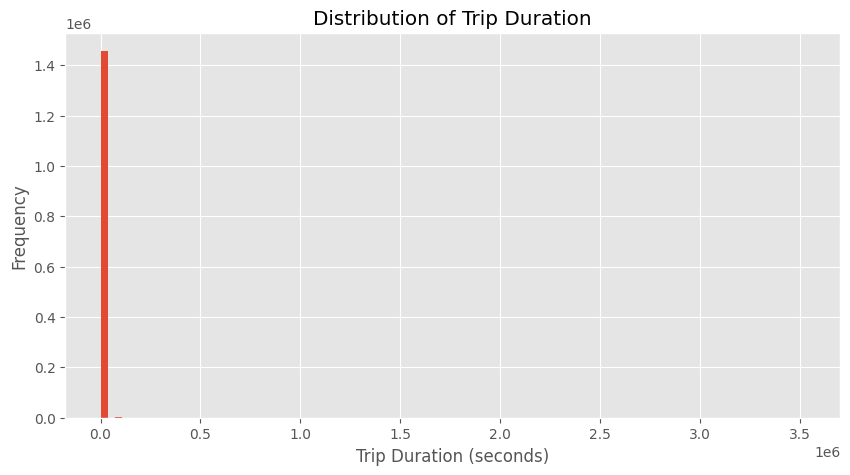

In [3]:
plt.figure(figsize=(10,5))

plt.hist(train_df["trip_duration"], bins=100)

plt.title("Distribution of Trip Duration")

plt.xlabel("Trip Duration (seconds)")

plt.ylabel("Frequency")

plt.show()

### Observation

The distribution is highly right-skewed.

A large number of taxi trips have relatively short durations, while a few trips have extremely long durations.

These extreme values indicate the presence of significant outliers.

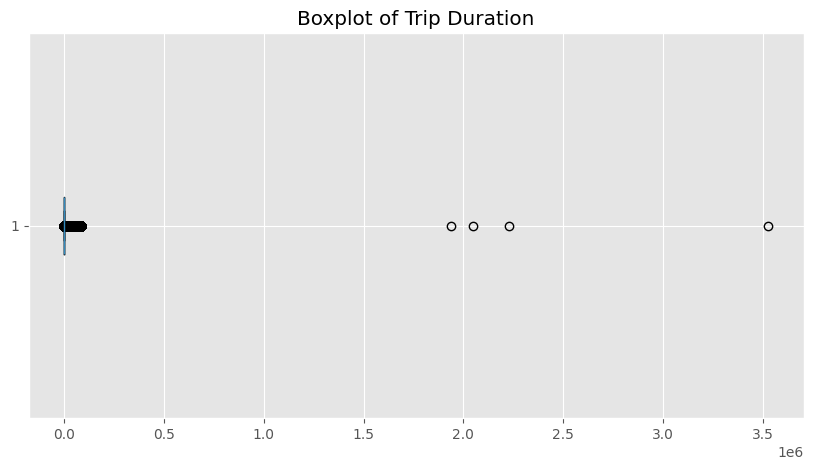

In [4]:
plt.figure(figsize=(10,5))

plt.boxplot(train_df["trip_duration"], vert=False)

plt.title("Boxplot of Trip Duration")

plt.show()

### Observation

The boxplot confirms the existence of extreme outliers.

These observations will be investigated further during preprocessing.

# 2. Passenger Count Analysis

### Question

How many passengers typically travel in a taxi?

In [5]:
train_df["passenger_count"].value_counts().sort_index()

passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64

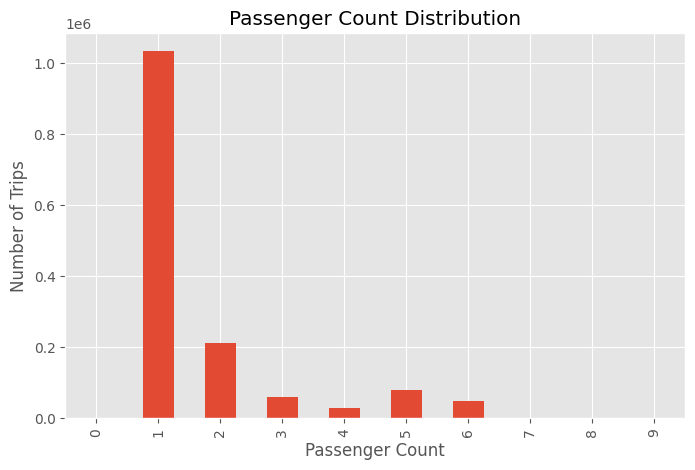

In [6]:
train_df["passenger_count"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Passenger Count Distribution")

plt.xlabel("Passenger Count")

plt.ylabel("Number of Trips")

plt.show()

### Observation

Most taxi trips involve a single passenger.

Passenger counts of **0** appear in the dataset and are likely invalid.

These records will be investigated during preprocessing.

# 3. Vendor Analysis

### Question

Do both vendors contribute equally to the dataset?

In [7]:
train_df["vendor_id"].value_counts()

vendor_id
2    780302
1    678342
Name: count, dtype: int64

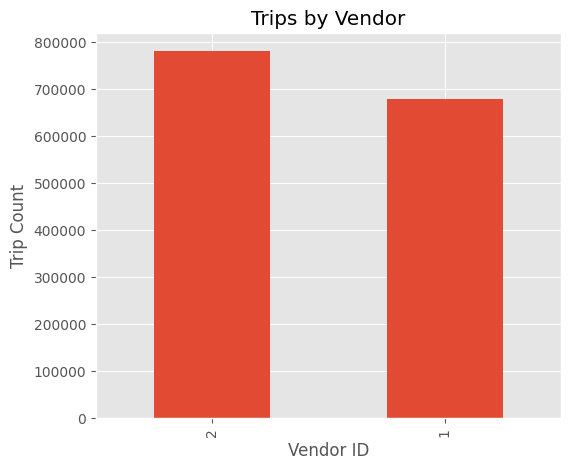

In [8]:
train_df["vendor_id"].value_counts().plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Trips by Vendor")

plt.xlabel("Vendor ID")

plt.ylabel("Trip Count")

plt.show()

### Observation

Both vendors contribute a substantial number of trips.

Any imbalance should be considered during model evaluation.

# 4. Store and Forward Flag

### Question

How common are store-and-forward trips?

In [9]:
train_df["store_and_fwd_flag"].value_counts()

store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64